# Practical End-to-End Example on sample1

This notebook shows one complete repository workflow in practice, using only 14 devices from `data/sample1`:
- 5 devices for train
- 5 devices for validation
- 4 device for test

Each device under the `data/sample1` contains a folder with many pcap or pcapng to be merged.

Pipeline steps:
1. Build one merged `.pcap` per device into `data/pcap/sample1` (in case of pcang, it is automatically converted)
2. Run PCAP parsing scripts
3. Run preprocessing and balancing scripts
4. Load balanced data and define cycle with train/test/val sets
5. Run one cycle for BAMBOO train/val/test
6. PF train/val/test
7. PINTOR val/test (no train needed)

In [1]:
import os
import shutil
from pathlib import Path
from configparser import ConfigParser
import numpy as np
import pandas as pd
from scapy.all import rdpcap, wrpcap
from modules.bamboo.bamboo_functions import train_bamboo
from modules.pf_training import train_pf
from modules.pair_generator import generate_balanced_pairs_df
from modules.bamboo_roc_validation import get_bamboo_validation_data
from modules.pf_roc_validation import get_pf_validation_data
from modules.pintor_roc_validation import get_pintor_validation_data
from modules.utils.validation_utils import (
    generate_combinations_df,
    get_bamboo_fprint_matrix,
    get_pf_fprint_matrix,
    prepare_pintor_features,
)
from modules.utils.clustering_utils import (
    validate_dbscan_on_bamboo_data,
    validate_dbscan_on_pf_data,
    validate_dbscan_on_pintor_data,
    test_dbscan_bamboo,
    test_dbscan_pf,
    test_dbscan_pintor,
    test_groupby_on_combinations,
)
from pcap_processing.parse_pcaps import parse_pcaps
from pre_processing.data_preprocess import data_preprocess
from pre_processing.device_analyzer import analyze_dev_distribution
from pre_processing.dataset_balancer import dataset_balancer

RANDOM_STATE = 42
PAIRS_PER_LABEL = 100
BITS_SET = [8, 16, 32, 64]
ENTRIES_PER_DEVICE = 500
repo_root = Path.cwd().resolve()
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
# SAMPLE DIR HERE
dataset_name = "sample1" # you can change this to something else if you have a different dataset, given that data is  organized in the same way as sample1 (pcaps in /data/sample1)

# path to the dataset folders
sample1_root = repo_root / "data" / dataset_name
merged_pcap_root = repo_root / "data" / "pcap" / dataset_name

binary_root = repo_root / "data" / "binary"
hex_root = repo_root / "data" / "hex"
dissected_root = repo_root / "data" / "dissected"
interim_root = repo_root / "data" / "interim"
filters_root = repo_root / "data" / "filters"
results_root = repo_root / "results"

for p in [merged_pcap_root, binary_root, hex_root, dissected_root, interim_root, filters_root, results_root]:
    p.mkdir(parents=True, exist_ok=True)

print("Repository root:", repo_root)
print("Sample1 root:", sample1_root)
print("Merged PCAP root:", merged_pcap_root)

Repository root: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026
Sample1 root: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1
Merged PCAP root: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\pcap\sample1


## Step 1: Inspect device captures and merge pcaps if needed

In [6]:
device_dirs = sorted([p for p in sample1_root.iterdir() if p.is_dir()])
print("Selected devices:")
for d in device_dirs:
    print(" -", d.name)


devices_requiring_concat = []
single_file_copied = 0

# for each device, check if there's a single capture file or multiple ones
# if single, copy it to the merged_pcap_root
# if multiple, add the device to the list of devices requiring concatenation
for src_dir in device_dirs:
    capture_files = sorted(list(src_dir.glob("*.pcap")) + list(src_dir.glob("*.pcapng")))
    if not capture_files:
        print(f"[WARNING] {src_dir.name}: no capture files found, skipping.")
        continue
        
    if len(capture_files) == 1:
        only_file = capture_files[0]
        target = merged_pcap_root / f"{src_dir.name}.pcap"
        if only_file.suffix.lower() == ".pcap":
            shutil.copy2(only_file, target)
            print(f"[COPY] {src_dir.name}: single file copied -> {target.name}")
        else:
            packets = rdpcap(str(only_file))
            wrpcap(str(target), packets)
            print(f"[COPY+CONVERT] {src_dir.name}: single .pcapng converted -> {target.name}")
        single_file_copied += 1
        
    else:
        devices_requiring_concat.append(src_dir.name)
        print(f"[CONCAT NEEDED] {src_dir.name}: {len(capture_files)} capture files found, will require concatenation.")

print(f"\nSummary: {single_file_copied} single files copied, {len(devices_requiring_concat)} devices need concat.")

Selected devices:
 - GooglePixel6A_AM_AR
 - HuaweiMediapadT5_GV_AR
 - iPad6_AN_AR
 - iPad9a_GV_AR
 - iPadAir11_RBM_AR
 - iPhone11_AM_AR
 - iPhone11_CM_AR
 - iPhone12Pro_DM_AR
 - iPhone13ProMax_AY_AR
 - iPhone14_MP_AR
 - iPhone14ProMax_RBM_AR
 - iPhone15Pro_AS_AR
 - iPhone15Pro_PG_AR
 - iPhone8_AY_AR
[CONCAT NEEDED] GooglePixel6A_AM_AR: 10 capture files found, will require concatenation.
[CONCAT NEEDED] HuaweiMediapadT5_GV_AR: 8 capture files found, will require concatenation.
[CONCAT NEEDED] iPad6_AN_AR: 4 capture files found, will require concatenation.
[CONCAT NEEDED] iPad9a_GV_AR: 8 capture files found, will require concatenation.
[CONCAT NEEDED] iPadAir11_RBM_AR: 4 capture files found, will require concatenation.
[CONCAT NEEDED] iPhone11_AM_AR: 4 capture files found, will require concatenation.
[CONCAT NEEDED] iPhone11_CM_AR: 4 capture files found, will require concatenation.
[CONCAT NEEDED] iPhone12Pro_DM_AR: 4 capture files found, will require concatenation.
[CONCAT NEEDED] iPhon

### Step 1B: Concatenate only multi-file devices

> We run `pcap_processing/concat_pcap.py` only for devices that have multiple capture files.

> If no device needs concatenation, the step is skipped.

In [7]:
# Step 1C: Run concat utility only for queued devices
if devices_requiring_concat:
    from pcap_processing.concat_pcap import process_all_subfolders
    # Build a temporary root with only the multi-file device folders
    print(f"Running concat_pcap on {len(devices_requiring_concat)} devices...")
    process_all_subfolders(str(sample1_root))
    
    # Collect merged outputs and copy to merged_pcap_root
    for base in devices_requiring_concat:
        out_pcap = sample1_root / f"{base}.pcap"
        out_pcapng = sample1_root / f"{base}.pcapng"
        
        if out_pcap.exists():
            shutil.copy2(out_pcap, merged_pcap_root / out_pcap.name)
            print(f"[OK] {base}: concatenated and copied {out_pcap.name}")
        elif out_pcapng.exists():
            packets = rdpcap(str(out_pcapng))
            converted = merged_pcap_root / f"{base}.pcap"
            wrpcap(str(converted), packets)
            print(f"[OK] {base}: concatenated {out_pcapng.name} and converted to {converted.name}")
        else:
            print(f"[WARN] No merged output found for {base}")
else:
    print("No device has multiple capture files: concat step skipped.")

print("\nMerged files available in:", merged_pcap_root)
files_in_merged = list(merged_pcap_root.glob("*.pcap"))
print(f"Total merged pcap files: {len(files_in_merged)}")

Running concat_pcap on 14 devices...
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\GooglePixel6A_AM_AR.pcapng from 10 pcapng file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\HuaweiMediapadT5_GV_AR.pcap from 8 pcap file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\iPad6_AN_AR.pcapng from 4 pcapng file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\iPad9a_GV_AR.pcap from 8 pcap file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\iPadAir11_RBM_AR.pcapng from 4 pcapng file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\iPhone11_AM_AR.pcapng from 4 pcapng file(s).
[+] Created C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\sample1\iPhone11_CM_AR.pca

## Step 2-3: Run pcap processing, preprocessing and balancing

Create config files for data processing

In [8]:
# create config files for pcap_processing and pre_processing
def create_config_file(config_dict, filename):
    config = ConfigParser()
    for section, params in config_dict.items():
        config[section] = params
    with open(filename, 'w') as configfile:
        config.write(configfile)
    print(f"Config file '{filename}' created with sections: {list(config_dict.keys())}")
# create config files
config_pcap_processing = {
    "SAMPLE1_NOTEBOOK": {
        "raw_path": str(merged_pcap_root) + os.sep,
        "dissected_path": str(dissected_root) + os.sep,
        "hex_path": str(hex_root) + os.sep,
        "binary_path": str(binary_root) + os.sep,
    }
}

config_data_preprocessing = {
    "DEFAULT": {
        "binary_path": str(binary_root) + os.sep,
        "hex_path": str(hex_root) + os.sep,
        "output_path": str(interim_root) + os.sep,
    },
    "FILTERS": {
        "filters_path": str(filters_root) + os.sep
    }
}
pcap_file_name = repo_root / "pcap_processing" / "config_pcap_processing_nb.ini"
pre_file_name = repo_root / "pre_processing" / "config_data_preprocessing_nb.ini"
create_config_file(config_pcap_processing, pcap_file_name)
create_config_file(config_data_preprocessing, pre_file_name)

Config file 'C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\config_pcap_processing_nb.ini' created with sections: ['SAMPLE1_NOTEBOOK']
Config file 'C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pre_processing\config_data_preprocessing_nb.ini' created with sections: ['DEFAULT', 'FILTERS']


#### Step 2: Parse pcaps: (from pcap to csv)

In [9]:
# run pcap processing (PCAP-> CSV)
print("\nStarting PCAP processing...")
parse_pcaps(config_file = pcap_file_name)


Starting PCAP processing...
Reading configuration from: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\config_pcap_processing_nb.ini
Processing dataset: SAMPLE1_NOTEBOOK
Hex Processing file: GooglePixel6A_AM_AR.pcap (1/14)
Hex Processing file: HuaweiMediapadT5_GV_AR.pcap (2/14)
Hex Processing file: iPad6_AN_AR.pcap (3/14)
Hex Processing file: iPad9a_GV_AR.pcap (4/14)
Hex Processing file: iPadAir11_RBM_AR.pcap (5/14)
Hex Processing file: iPhone11_AM_AR.pcap (6/14)
Hex Processing file: iPhone11_CM_AR.pcap (7/14)
Hex Processing file: iPhone12Pro_DM_AR.pcap (8/14)
Hex Processing file: iPhone13ProMax_AY_AR.pcap (9/14)
Hex Processing file: iPhone14ProMax_RBM_AR.pcap (10/14)
Hex Processing file: iPhone14_MP_AR.pcap (11/14)
Hex Processing file: iPhone15Pro_AS_AR.pcap (12/14)
Hex Processing file: iPhone15Pro_PG_AR.pcap (13/14)
Hex Processing file: iPhone8_AY_AR.pcap (14/14)
Binary Processing file: GooglePixel6A_AM_AR.pcap (1/14)


[12:36:04] INFO     [12:36:04] Writing GooglePixel6A_AM_AR.csv                                    ]8;id=799173;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py\fileUtility.py]8;;\:]8;id=454964;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py#33\33]8;;\

Binary Processing file: HuaweiMediapadT5_GV_AR.pcap (2/14)


[12:36:12] INFO     [12:36:12] Writing HuaweiMediapadT5_GV_AR.csv                                 ]8;id=331860;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py\fileUtility.py]8;;\:]8;id=109613;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py#33\33]8;;\

Binary Processing file: iPad6_AN_AR.pcap (3/14)


...

[12:36:50] INFO     [12:36:50] Writing iPhone15Pro_AS_AR.csv                                      ]8;id=873108;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py\fileUtility.py]8;;\:]8;id=210231;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py#33\33]8;;\

Dissector Processing file: iPhone15Pro_PG_AR.pcap (13/14)


[12:36:51] INFO     [12:36:51] Writing iPhone15Pro_PG_AR.csv                                      ]8;id=671940;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py\fileUtility.py]8;;\:]8;id=358888;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py#33\33]8;;\

Dissector Processing file: iPhone8_AY_AR.pcap (14/14)


           INFO     [12:36:51] Writing iPhone8_AY_AR.csv                                          ]8;id=348584;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py\fileUtility.py]8;;\:]8;id=730410;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\pcap_processing\utils\fileUtility.py#33\33]8;;\

#### Step 3A: pre-processing (CSV cleaning, binary concatenation, filters generation)

In [10]:
print("\nStarting data pre-processing...")
data_preprocess(config_file = pre_file_name)



Starting data pre-processing...
Loaded binary dataframe shape: (15168, 30)
Average length of the column mac: 17.0
Average length of the column dsss_parameter: 8.0
Average length of the column len_ht_cap: 8.0
Average length of the column ht_cap: 208.0
Average length of the column len_ext_cap: 8.0
Average length of the column ext_cap: 96.0
Average length of the column len_vst: 8.0
Average length of the column vst: 1400.0
Average length of the column label: 18.71268459915612
Average length of the column concatenated: 1736.0
Saved dataframe with concatenated binary features to: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\interim\binary_U_concatenated.csv. Shape: (15168, 2)
Average length of the concatenated column: 1736.0
Saved dataframe with concatenated hex features to: C:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\data\interim\hex_full.csv. Shape: (15168, 14)
Generating filters dataframe based on the concatenated binary features.

#### Step 3B: Dataset Balancing

Analyze device probe distribution before balancing


Analyzing device distribution...
(15168, 2)
Label: GooglePixel6A_AM_AR - Number of entries: 105, Number of unique entries: 17
Label: HuaweiMediapadT5_GV_AR - Number of entries: 6311, Number of unique entries: 239
Label: iPad6_AN_AR - Number of entries: 32, Number of unique entries: 4
Label: iPad9a_GV_AR - Number of entries: 2431, Number of unique entries: 127
Label: iPadAir11_RBM_AR - Number of entries: 1286, Number of unique entries: 13
Label: iPhone11_AM_AR - Number of entries: 75, Number of unique entries: 14
Label: iPhone11_CM_AR - Number of entries: 709, Number of unique entries: 5
Label: iPhone12Pro_DM_AR - Number of entries: 17, Number of unique entries: 2
Label: iPhone13ProMax_AY_AR - Number of entries: 26, Number of unique entries: 2
Label: iPhone14ProMax_RBM_AR - Number of entries: 2596, Number of unique entries: 11
Label: iPhone14_MP_AR - Number of entries: 44, Number of unique entries: 1
Label: iPhone15Pro_AS_AR - Number of entries: 1233, Number of unique entries: 1
Label:

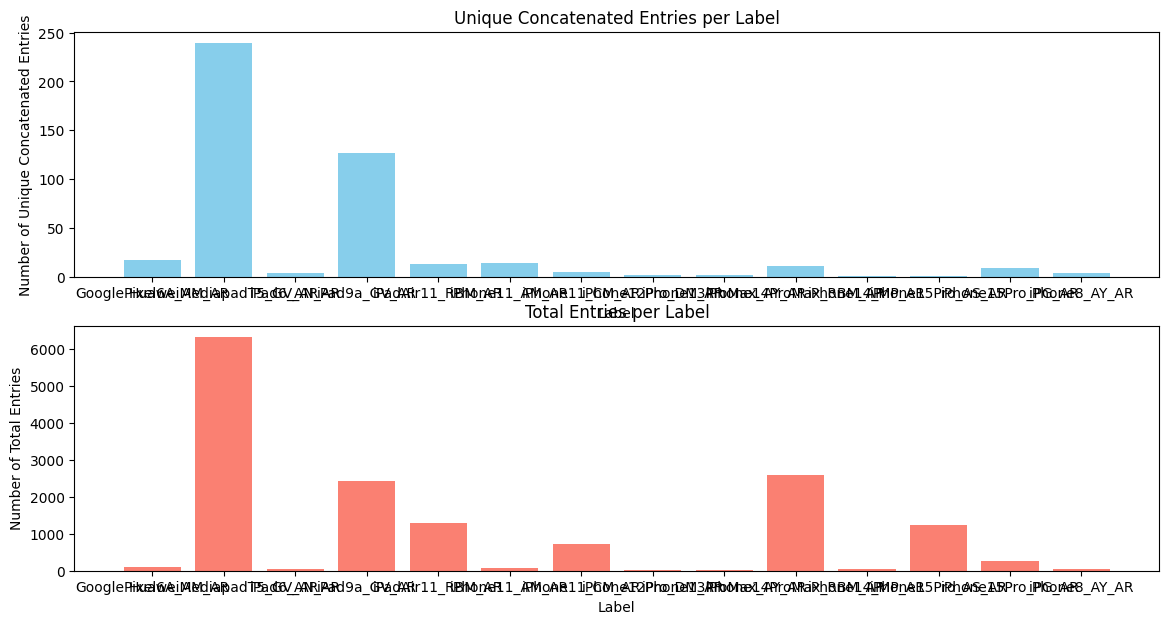

In [11]:
import logging
import pre_processing.device_analyzer as device_analyzer
# Silence verbose matplotlib debug output in notebook cells.
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.pyplot").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

print("\nAnalyzing device distribution...")
device_analyzer.analyze_dev_distribution(config_file=pre_file_name, concatenate_file="binary_U_concatenated.csv")


Now balance the dataset and show again the distribution


Balancing dataset...
Showing device distribution after balancing...
(7000, 2)
Label: GooglePixel6A_AM_AR - Number of entries: 500, Number of unique entries: 17
Label: HuaweiMediapadT5_GV_AR - Number of entries: 500, Number of unique entries: 93
Label: iPad6_AN_AR - Number of entries: 500, Number of unique entries: 4
Label: iPad9a_GV_AR - Number of entries: 500, Number of unique entries: 69
Label: iPadAir11_RBM_AR - Number of entries: 500, Number of unique entries: 13
Label: iPhone11_AM_AR - Number of entries: 500, Number of unique entries: 14
Label: iPhone11_CM_AR - Number of entries: 500, Number of unique entries: 5
Label: iPhone12Pro_DM_AR - Number of entries: 500, Number of unique entries: 2
Label: iPhone13ProMax_AY_AR - Number of entries: 500, Number of unique entries: 2
Label: iPhone14ProMax_RBM_AR - Number of entries: 500, Number of unique entries: 10
Label: iPhone14_MP_AR - Number of entries: 500, Number of unique entries: 1
Label: iPhone15Pro_AS_AR - Number of entries: 500, Nu

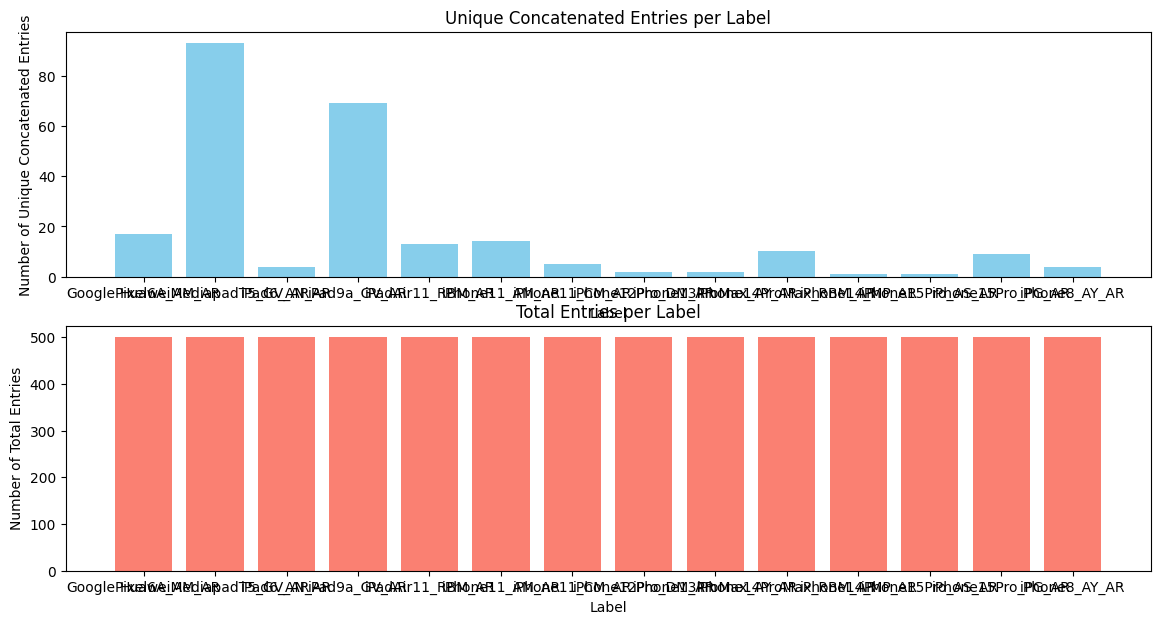

In [12]:
# analyze device distribution

# balance dataset
print("\nBalancing dataset...")
dataset_balancer(n_entries_per_devices = ENTRIES_PER_DEVICE, config_file = pre_file_name)

print("Showing device distribution after balancing...")
device_analyzer.analyze_dev_distribution(config_file=pre_file_name, concatenate_file="binary_U_balanced.csv")

## Step 4: Load balanced data and define one 5-device cycle (2 train, 2 val, 1 test)

In [5]:

bin_0_df = pd.read_csv(interim_root / "binary_0_balanced.csv", dtype=str)
bin_u_df = pd.read_csv(interim_root / "binary_U_balanced.csv", dtype=str)
hex_df = pd.read_csv(interim_root / "hex_full_balanced.csv", dtype=str)
bamboo_filters_df = pd.read_csv(filters_root / "bitmask_patterns_sliding_window.csv", dtype=str)

if "label" not in bin_0_df.columns:
    bin_0_df["label"] = bin_0_df.index.astype(str)
if "label" not in bin_u_df.columns:
    bin_u_df["label"] = bin_u_df.index.astype(str)

if "Label" not in hex_df.columns and "label" in hex_df.columns:
    hex_df["Label"] = hex_df["label"]

available_labels = sorted(bin_u_df["label"].unique().tolist())
if len(available_labels) < 5:
    raise RuntimeError(f"Need at least 5 labels after balancing, found {len(available_labels)}")

rng = np.random.default_rng(RANDOM_STATE)
selected_labels = available_labels
rng.shuffle(selected_labels)

# take 35% of the labels for training, 35% for validation, and 50% for testing (if not divisible, the remaining labels go to training)
n_train = int(np.round(0.35 * len(selected_labels)))
n_val = int(np.round(0.35 * len(selected_labels)))
n_test = int(len(selected_labels) - n_val - n_train)
print(f"Total labels: {len(selected_labels)}, Train: {n_train}, Val: {n_val}, Test: {n_test}")

train_labels = selected_labels[:n_train]
val_labels = selected_labels[n_train:n_train + n_val]
test_labels = selected_labels[n_train + n_val:n_train + n_val + n_test]

print("Selected labels:", selected_labels)
print("Train labels:", train_labels)
print("Val labels:", val_labels)
print("Test labels:", test_labels)

(results_root / "bamboo").mkdir(parents=True, exist_ok=True)
(results_root / "pf").mkdir(parents=True, exist_ok=True)
(results_root / "pintor").mkdir(parents=True, exist_ok=True)

with open(results_root / "labels.txt", "w", encoding="utf-8") as f:
    f.write("TRAIN LABELS\n" + "\n".join(train_labels) + "\n\n")
    f.write("VAL LABELS\n" + "\n".join(val_labels) + "\n\n")
    f.write("TEST LABELS\n" + "\n".join(test_labels) + "\n")

validation_pairs_df = generate_balanced_pairs_df(
    bin_0_df[bin_0_df["label"].isin(val_labels)].copy(),
    pairs_per_label=PAIRS_PER_LABEL,
    random_state=RANDOM_STATE,
)
validation_pairs_df.to_csv(results_root / "validation_pairs.csv", index=False)

# DBSCAN helper: clustering combinations require at least 2 labels.
effective_test_labels = list(test_labels)
if len(effective_test_labels) < 2:
    effective_test_labels = test_labels + [val_labels[0]]

val_combinations_df = generate_combinations_df(val_labels, max_combinations_per_M=10, random_state=RANDOM_STATE)
test_combinations_df = generate_combinations_df(effective_test_labels, max_combinations_per_M=20, random_state=RANDOM_STATE)

val_combinations_df.to_csv(results_root / "val_combinations.csv", index=False)
test_combinations_df.to_csv(results_root / "test_combinations.csv", index=False)

print("Validation pairs:", validation_pairs_df.shape)
print("Validation combinations:", val_combinations_df.shape)
print("Test combinations:", test_combinations_df.shape)

bamboo_output_file = results_root / "bamboo" / "bamboo_output.csv"


Total labels: 14, Train: 5, Val: 5, Test: 4
Selected labels: ['iPhone11_CM_AR', 'iPhone12Pro_DM_AR', 'iPhone14ProMax_RBM_AR', 'iPad9a_GV_AR', 'GooglePixel6A_AM_AR', 'iPhone15Pro_AS_AR', 'iPhone8_AY_AR', 'iPhone14_MP_AR', 'iPhone11_AM_AR', 'iPad6_AN_AR', 'iPadAir11_RBM_AR', 'iPhone15Pro_PG_AR', 'HuaweiMediapadT5_GV_AR', 'iPhone13ProMax_AY_AR']
Train labels: ['iPhone11_CM_AR', 'iPhone12Pro_DM_AR', 'iPhone14ProMax_RBM_AR', 'iPad9a_GV_AR', 'GooglePixel6A_AM_AR']
Val labels: ['iPhone15Pro_AS_AR', 'iPhone8_AY_AR', 'iPhone14_MP_AR', 'iPhone11_AM_AR', 'iPad6_AN_AR']
Test labels: ['iPadAir11_RBM_AR', 'iPhone15Pro_PG_AR', 'HuaweiMediapadT5_GV_AR', 'iPhone13ProMax_AY_AR']
Validation pairs: (1000, 5)
Validation combinations: (26, 2)
Test combinations: (11, 2)


# Step 5: Apply  BAMBOO Train -> Validation -> Test

Step 4A: Train Bamboo (may take a while to get all the 64 filters)

In [ ]:
bamboo_train_df = bin_u_df[bin_u_df["label"].isin(train_labels)].copy()
train_pairs_df = generate_balanced_pairs_df(
    bamboo_train_df,
    pairs_per_label=PAIRS_PER_LABEL,
    random_state=RANDOM_STATE,
)
train_pairs_df.to_csv(results_root / "train_pairs.csv", index=False)

print("Training BAMBOO...")
train_bamboo(
    bin_u_df,
    train_pairs_df,
    bamboo_filters_df,
    bamboo_output_file=str(bamboo_output_file),
    n_iterations=64,
    n_filters=0,
    max_workers=2,
)


Training BAMBOO...
  ___________________
| Boosting some bits! |
                       \
                       \  
                               /`·.¸
                           /¸...¸`:·
                       ¸.·´  ¸   `·.¸.·´)
                       : © ):´;      ¸  {
                       `·.¸ `·  ¸.·´\`·¸)
                           `\\´´\¸.·´
                       
Reshaping from (12152000,) to (7000, 1736)


[12:43:31] WARNING  [12:43:31] There are 2 configurations with the minimum error.           ]8;id=6494;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=82092;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:43:41] WARNING  [12:43:41] There are 6846 configurations with the minimum error.        ]8;id=865528;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=307117;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:43:43] WARNING  [12:43:43] There are 6838 configurations with the minimum error.        ]8;id=852740;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=132340;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:43:45] WARNING  [12:43:45] There are 6830 configurations with the minimum error.        ]8;id=711406;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=748420;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

...

[12:45:19] WARNING  [12:45:19] There are 6492 configurations with the minimum error.        ]8;id=502604;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=684280;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:45:21] WARNING  [12:45:21] There are 6484 configurations with the minimum error.        ]8;id=347127;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=123147;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:45:23] WARNING  [12:45:23] There are 6476 configurations with the minimum error.        ]8;id=970770;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=301194;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:45:24] WARNING  [12:45:24] There are 6468 configurations with the minimum error.        ]8;id=233453;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=189207;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

[12:45:26] WARNING  [12:45:26] There are 6460 configurations with the minimum error.        ]8;id=560556;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py\bamboo_functions.py]8;;\:]8;id=876305;file://c:\Users\fabio\Ricerca\Codice\Probe-Bamboo-2026-repo\Probe-Bamboo-2026\modules\bamboo\bamboo_functions.py#265\265]8;;\

### Step 4B: apply ROC validation for Bamboo

Running BAMBOO ROC validation...


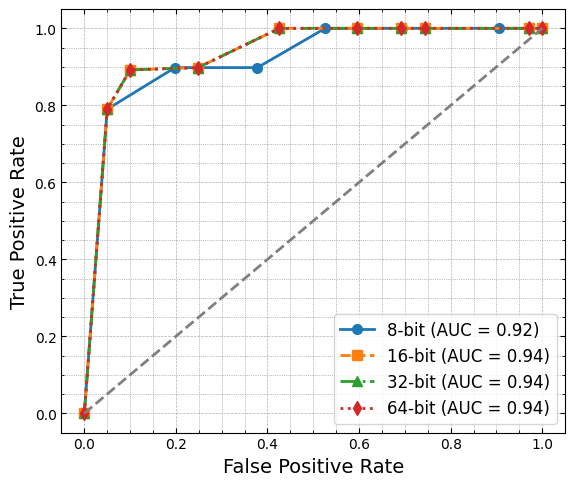

In [7]:
print("Running BAMBOO ROC validation...")
best_taus_bamboo = get_bamboo_validation_data(
    bin_0_df,
    validation_pairs_df,
    str(bamboo_output_file),
    bits_set=BITS_SET,
    hamming=False,
    roc_save_path=str(results_root / "bamboo"),
    show_plot=True
)
best_taus_bamboo_hamming = get_bamboo_validation_data(
    bin_0_df,
    validation_pairs_df,
    str(bamboo_output_file),
    bits_set=BITS_SET,
    hamming=True,
    roc_save_path=str(results_root / "bamboo")
)
best_taus_bamboo.to_csv(results_root / "bamboo" / "bamboo_best_taus.csv", index=False)
best_taus_bamboo_hamming.to_csv(results_root / "bamboo" / "bamboo_best_taus_hamming.csv", index=False)




### Step 4C: Run DBSCAN validation to get the best parameters

In [8]:
print("Running BAMBOO DBSCAN validation...")
bamboo_val_df = bin_0_df[bin_0_df["label"].isin(val_labels)].copy()
bamboo_val_df = get_bamboo_fprint_matrix(bamboo_val_df, str(bamboo_output_file))
bamboo_val_df.to_csv(results_root / "bamboo" / "bamboo_val_df_with_fprints.csv", index=False)
validate_dbscan_on_bamboo_data(bamboo_val_df, val_combinations_df, output_folder=str(results_root / "bamboo"))

Running BAMBOO DBSCAN validation...
Validating DBSCAN for BAMBOO for n_bit = 8
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for BAMBOO for n_bit = 16
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for BAMBOO for n_bit = 32
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for BAMBOO for n_bit = 64
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...


#### Step 4C: Run DBSCAN test with best params (also use groupby as reference clustering to compare)

In [11]:

print("Running BAMBOO cluster test...")
bamboo_test_df = bin_0_df[bin_0_df["label"].isin(effective_test_labels)].copy()
bamboo_test_df = get_bamboo_fprint_matrix(bamboo_test_df, str(bamboo_output_file))
bamboo_test_df.to_csv(results_root / "bamboo" / "bamboo_test_df_with_fprints.csv", index=False)

for n_bits in BITS_SET:
    X = bamboo_test_df[["bamboo_fprint"]].copy()
    X["bamboo_fprint"] = X["bamboo_fprint"].apply(lambda f: f[:n_bits])
    groupby_res = test_groupby_on_combinations(X, bamboo_test_df["label"], test_combinations_df)
    groupby_res.to_csv(results_root / "bamboo" / f"groupby_test_results_{n_bits}_bits.csv", index=False)

    best_res_df = pd.read_csv(results_root / "bamboo" / f"best_dbscan_params_{n_bits}_bits.csv")
    dbscan_res = test_dbscan_bamboo(bamboo_test_df, test_combinations_df, best_res_df, num_bits=n_bits)
    dbscan_res.to_csv(results_root / "bamboo" / f"dbscan_test_results_{n_bits}_bits.csv", index=False)

display(groupby_res)
display(dbscan_res)

Running BAMBOO cluster test...


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
1,0.850632,0.519863,0.645332,0.721172,0.645332,0.0,13,0.161245,2
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,1,0.707107,2
3,0.557367,0.269086,0.362948,0.302678,0.362948,0.0,14,0.344964,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
5,0.850632,0.519863,0.645332,0.721172,0.645332,0.0,13,0.161245,2
6,0.750993,0.541141,0.629026,0.604917,0.629026,0.0,14,0.310913,3
7,0.579380,0.654126,0.614488,0.416331,0.614488,0.0,4,0.577350,3
8,0.505817,0.604850,0.550918,0.419151,0.550918,0.0,13,1.162182,3
9,0.750993,0.541141,0.629026,0.604917,0.629026,0.0,14,0.578504,3


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
1,0.850632,0.522417,0.647296,0.721196,0.647296,0.004000,9,0.204939,2
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1,0.707107,2
3,0.557367,0.270130,0.363896,0.302702,0.363896,0.004000,10,0.350714,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
5,0.850632,0.522417,0.647296,0.721196,0.647296,0.004000,9,0.173205,2
6,0.750993,0.542456,0.629914,0.604931,0.629914,0.002667,10,0.327618,3
7,0.579380,0.654126,0.614488,0.416331,0.614488,0.000000,4,0.577350,3
8,0.505817,0.607294,0.551930,0.419163,0.551930,0.002667,9,1.166762,3
9,0.750993,0.542456,0.629914,0.604931,0.629914,0.002667,10,0.580804,3


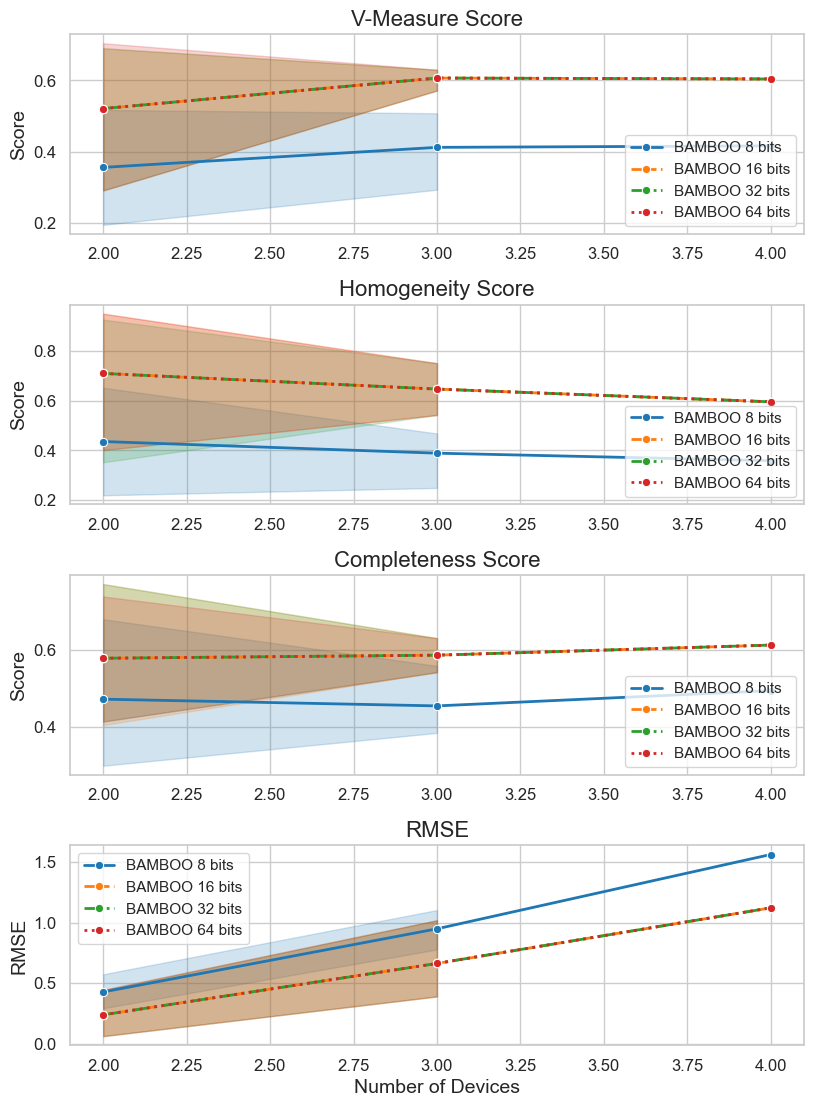

In [20]:
# now compare the results in a single figure
from modules.compare_results import plot_clustering_metrics
bamboo_results_8 = pd.read_csv(results_root / "bamboo" / f"dbscan_test_results_8_bits.csv")
bamboo_results_16 = pd.read_csv(results_root / "bamboo" / f"dbscan_test_results_16_bits.csv")
bamboo_results_32 = pd.read_csv(results_root / "bamboo" / f"dbscan_test_results_32_bits.csv")
bamboo_results_64 = pd.read_csv(results_root / "bamboo" / f"dbscan_test_results_64_bits.csv")
plot_clustering_metrics([bamboo_results_8, bamboo_results_16, bamboo_results_32, bamboo_results_64], 
                            ["BAMBOO 8 bits", "BAMBOO 16 bits", "BAMBOO 32 bits", "BAMBOO 64 bits"], 
                            output_file = str(results_root / "bamboo_dbscan_comparison.pdf")
)

### Step 6: PF Train -> Validation -> Test

In [ ]:
pf_train_df = bin_u_df[bin_u_df["label"].isin(train_labels)].copy()

print("Training PF...")
for num_bits in BITS_SET:
    pf_indexes = train_pf(pf_train_df, num_bits=num_bits)
    pf_indexes.to_csv(results_root / "pf" / f"pf_indexes_{num_bits}bits.csv", index=False)

print("Running PF ROC validation...")
pf_index_files = [str(results_root / "pf" / f"pf_indexes_{num_bits}bits.csv") for num_bits in BITS_SET]
best_taus_pf = get_pf_validation_data(
    bin_0_df,
    validation_pairs_df,
    pf_index_files,
    bits_set=BITS_SET,
    roc_save_path=str(results_root / "pf"),
)
best_taus_pf.to_csv(results_root / "pf" / "pf_best_taus.csv", index=False)

print("Running PF DBSCAN validation...")
pf_val_df = bin_0_df[bin_0_df["label"].isin(val_labels)].copy()
pf_val_df = get_pf_fprint_matrix(pf_val_df, index_filenames=pf_index_files, bits_set=BITS_SET)
pf_val_df.to_csv(results_root / "pf" / "pf_val_df_with_fprints.csv", index=False)
validate_dbscan_on_pf_data(pf_val_df, val_combinations_df, output_folder=str(results_root / "pf"))

print("Running PF cluster test...")
pf_test_df = bin_0_df[bin_0_df["label"].isin(effective_test_labels)].copy()
pf_test_df = get_pf_fprint_matrix(pf_test_df, index_filenames=pf_index_files, bits_set=BITS_SET)
pf_test_df.to_csv(results_root / "pf" / "pf_test_df_with_fprints.csv", index=False)

for n_bits in BITS_SET:
    groupby_res = test_groupby_on_combinations(pf_test_df[f"pf_fprint_{n_bits}"], pf_test_df["label"], test_combinations_df)
    groupby_res.to_csv(results_root / "pf" / f"groupby_test_results_{n_bits}_bits.csv", index=False)

    best_res_df = pd.read_csv(results_root / "pf" / f"best_dbscan_params_{n_bits}_bits.csv")
    dbscan_res = test_dbscan_pf(pf_test_df, test_combinations_df, best_res_df, num_bits=n_bits)
    dbscan_res.to_csv(results_root / "pf" / f"dbscan_test_results_{n_bits}_bits.csv", index=False)

display(groupby_res)
display(dbscan_res)

Training PF...
Running PF ROC validation...
Validating PF with 8 bits...
Validating PF with 16 bits...
Validating PF with 32 bits...
Validating PF with 64 bits...
   num_bits  best_tau    tpr  fpr  dist_to_(0,1)
0         8      -0.0  0.994  0.0          0.006
1        16      -0.0  0.994  0.0          0.006
2        32      -0.0  0.994  0.0          0.006
3        64       1.0  0.994  0.0          0.006
Running PF DBSCAN validation...
Validating DBSCAN for PF for n_bit = 8
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for PF for n_bit = 16
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for PF for n_bit = 32
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for PF for n_bit = 64
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Running PF cluster test...


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
1,0.873033,0.463237,0.605299,0.702314,0.605299,0.008000,19,0.230217,2
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1,0.707107,2
3,0.990489,0.362183,0.530414,0.440753,0.530414,0.007000,22,0.089443,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
5,0.873033,0.463237,0.605299,0.702314,0.605299,0.008000,19,0.170294,2
6,0.942594,0.562315,0.704408,0.671110,0.704408,0.004667,22,0.182574,3
7,0.579380,0.654126,0.614488,0.416331,0.614488,0.000000,4,0.577350,3
8,0.517273,0.548672,0.532510,0.411103,0.532510,0.005333,19,1.169900,3
9,0.942594,0.562315,0.704408,0.671110,0.704408,0.004667,22,0.146059,3


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
1,0.873033,0.453197,0.596663,0.702094,0.596663,0.0,30,0.144914,2
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,1,0.707107,2
3,0.990489,0.357296,0.525155,0.440560,0.525155,0.0,32,0.031623,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
5,0.873033,0.453197,0.596663,0.702094,0.596663,0.0,30,0.144914,2
6,0.942594,0.557086,0.700291,0.670994,0.700291,0.0,32,0.121106,3
7,0.579380,0.654126,0.614488,0.416331,0.614488,0.0,4,0.577350,3
8,0.517273,0.538638,0.527740,0.410988,0.527740,0.0,30,1.160747,3
9,0.942594,0.557086,0.700291,0.670994,0.700291,0.0,32,0.129099,3


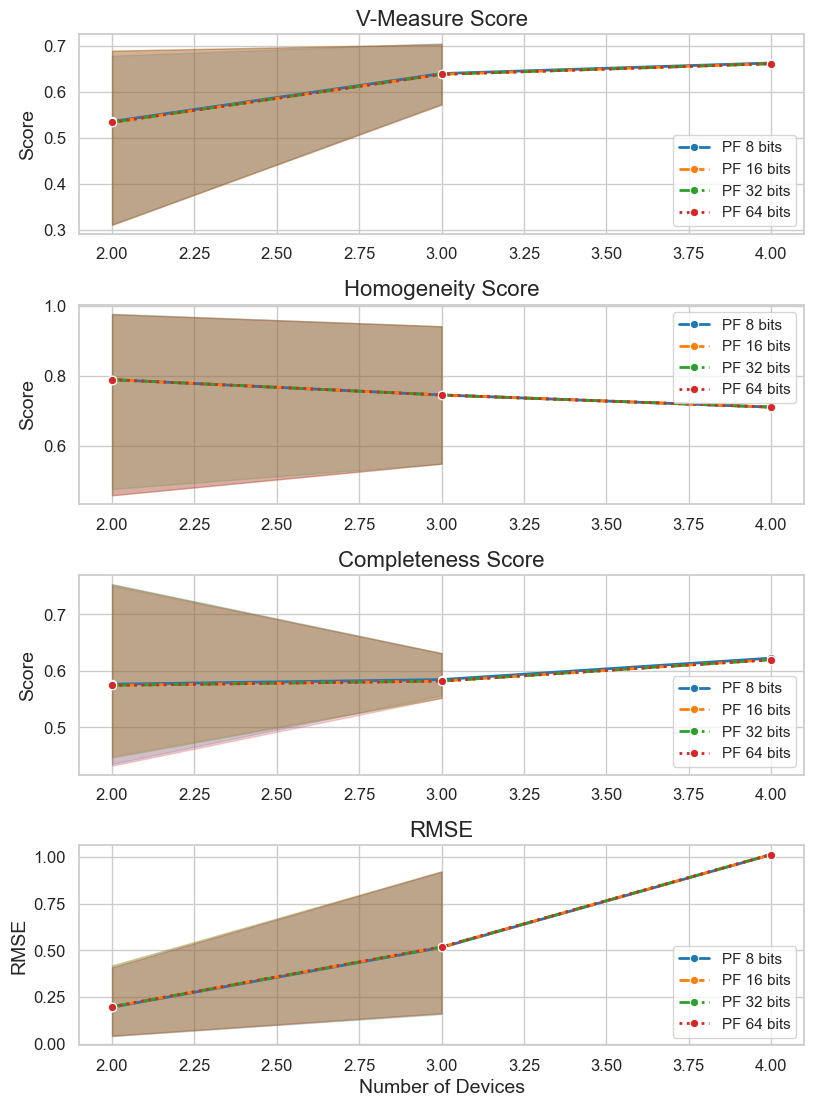

In [23]:
# now compare the results in a single figure
from modules.compare_results import plot_clustering_metrics
pf_results_8 = pd.read_csv(results_root / "pf" / f"dbscan_test_results_8_bits.csv")
pf_results_16 = pd.read_csv(results_root / "pf" / f"dbscan_test_results_16_bits.csv")
pf_results_32 = pd.read_csv(results_root / "pf" / f"dbscan_test_results_32_bits.csv")
pf_results_64 = pd.read_csv(results_root / "pf" / f"dbscan_test_results_64_bits.csv")

plot_clustering_metrics([pf_results_8, pf_results_16, pf_results_32, pf_results_64], 
                            ["PF 8 bits", "PF 16 bits", "PF 32 bits", "PF 64 bits"], 
                            output_file = str(results_root / "pf_dbscan_comparison.pdf")
)

### Step 7: PINTOR Validation -> Test


In [24]:
print("Running PINTOR ROC validation...")
best_tau_2 = get_pintor_validation_data(
    hex_df,
    validation_pairs_df,
    columns=["Extended Capabilities", "Vendor Specific Tags"],
    roc_save_path=str(results_root / "pintor"),
)
best_tau_3 = get_pintor_validation_data(
    hex_df,
    validation_pairs_df,
    columns=["HT Capabilities", "Extended Capabilities", "Vendor Specific Tags"],
    roc_save_path=str(results_root / "pintor"),
)

with open(results_root / "pintor" / "pintor_best_tau.txt", "w", encoding="utf-8") as f:
    f.write(f"Best tau (2 cols): {best_tau_2}\n")
    f.write(f"Best tau (3 cols): {best_tau_3}\n")

print("Running PINTOR DBSCAN validation...")
pintor_val_df = hex_df[hex_df["Label"].isin(val_labels)].copy()
pintor_val_df = prepare_pintor_features(
    pintor_val_df,
    columns=["HT Capabilities", "Extended Capabilities", "Vendor Specific Tags"],
    norm=False,
)
pintor_val_df.to_csv(results_root / "pintor" / "pintor_val_df_prepared.csv", index=False)
validate_dbscan_on_pintor_data(pintor_val_df, val_combinations_df, output_folder=str(results_root / "pintor"))

print("Running PINTOR cluster test...")
pintor_test_df_norm = hex_df[hex_df["Label"].isin(effective_test_labels)].copy()
pintor_test_df_norm = prepare_pintor_features(
    pintor_test_df_norm,
    columns=["HT Capabilities", "Extended Capabilities", "Vendor Specific Tags"],
    norm=True,
)
pintor_test_df_norm.to_csv(results_root / "pintor" / "pintor_test_df_prepared_norm.csv", index=False)

pintor_test_df = hex_df[hex_df["Label"].isin(effective_test_labels)].copy()
pintor_test_df = prepare_pintor_features(
    pintor_test_df,
    columns=["HT Capabilities", "Extended Capabilities", "Vendor Specific Tags"],
    norm=False,
)
pintor_test_df.to_csv(results_root / "pintor" / "pintor_test_df_prepared.csv", index=False)

cols = ["HT Capabilities", "Extended Capabilities", "Vendor Specific Tags"]
for n_cols in [2, 3]:
    selected_columns = cols[-n_cols:]

    groupby_res = test_groupby_on_combinations(
        pintor_test_df_norm[selected_columns],
        pintor_test_df_norm["Label"],
        test_combinations_df,
    )
    groupby_res.to_csv(results_root / "pintor" / f"groupby_test_results_{n_cols}_cols.csv", index=False)

    best_res_df = pd.read_csv(results_root / "pintor" / f"best_dbscan_params_{n_cols}_cols.csv")
    dbscan_res = test_dbscan_pintor(pintor_test_df, test_combinations_df, best_res_df=best_res_df, n_cols=n_cols)
    dbscan_res.to_csv(results_root / "pintor" / f"dbscan_test_results_{n_cols}_cols.csv", index=False)

display(groupby_res)
display(dbscan_res)

Running PINTOR ROC validation...
Running PINTOR DBSCAN validation...
Validating DBSCAN for PINTOR for n_col = 2
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Validating DBSCAN for PINTOR for n_col = 3
Evaluating DBSCAN for M=2...
Evaluating DBSCAN for M=4...
Running PINTOR cluster test...


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
1,1.000000,0.472725,0.641974,0.742600,0.641974,0.0,37,0.000000,2
2,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,2,0.000000,2
3,0.990489,0.349475,0.516658,0.439025,0.516658,0.0,38,0.031623,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.0,4,0.000000,2
5,1.000000,0.472725,0.641974,0.742600,0.641974,0.0,37,0.000000,2
6,0.995999,0.562233,0.718742,0.690698,0.718742,0.0,39,0.025820,3
7,1.000000,0.765490,0.867170,0.840777,0.867170,0.0,5,0.000000,3
8,1.000000,0.680663,0.809993,0.865505,0.809993,0.0,38,0.000000,3
9,0.995999,0.562233,0.718742,0.690698,0.718742,0.0,39,0.051640,3


,homogeneity,completeness,v_measure,ari,nmi,noise_ratio,n_clusters,rmse,length
0,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
1,1.000000,0.478372,0.647161,0.742464,0.647161,0.012000,26,0.219089,2
2,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2,0.000000,2
3,0.990489,0.351960,0.519368,0.438845,0.519368,0.011000,28,0.109545,2
4,1.000000,0.578592,0.733048,0.697654,0.733048,0.000000,4,0.000000,2
5,1.000000,0.478372,0.647161,0.742464,0.647161,0.012000,26,0.109545,2
6,0.995999,0.564916,0.720931,0.690588,0.720931,0.007333,29,0.173205,3
7,1.000000,0.765490,0.867170,0.840777,0.867170,0.000000,5,0.000000,3
8,1.000000,0.685564,0.813454,0.865430,0.813454,0.008000,27,0.178885,3
9,0.995999,0.564916,0.720931,0.690588,0.720931,0.007333,29,0.100000,3


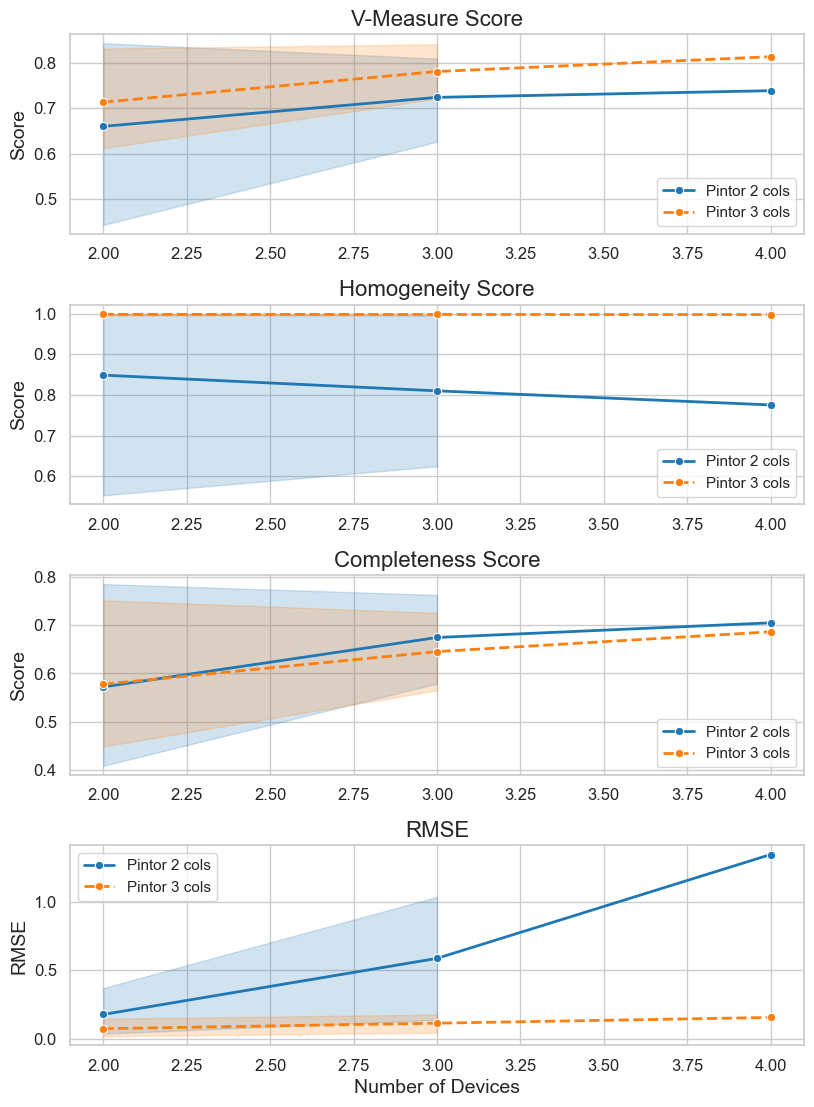

In [25]:
# now compare the results in a single figure
from modules.compare_results import plot_clustering_metrics
pintor_results_2 = pd.read_csv(results_root / "pintor" / f"dbscan_test_results_2_cols.csv")
pintor_results_3 = pd.read_csv(results_root / "pintor" / f"dbscan_test_results_3_cols.csv")

plot_clustering_metrics([pintor_results_2, pintor_results_3], 
                            ["Pintor 2 cols", "Pintor 3 cols"], 
                            output_file = str(results_root / "pintor_dbscan_comparison.pdf")
)